### Nomenclature 
NN      Neural Network  
PINN       Physics-Informed Neural Network
___

# Tasks

### Implementation 
This experiment focuses on executing the PINN rather than implementing it.
Therefore, large portions of the code are already provided.
First, gain an understanding of the model you are working with, and then complete the implementation.

1. __Understand code__
    1. Visualize imported data.
    2. inspect the `create_training_data` function, the `PINN` class and the `execute` function.
    3. Take notes for future evaluation.
<br><br>

2. __Implement Loss__
    1. Complete the `compute_boundary_loss` function.
    2. Complete the `compute_initial_loss` function.
    3. Complete the `compute_physics_informed_loss` function.
<br><br>
  
3. __Verify functionality__
    1. execute the network training.
    2. Visualize the the network prediction using the `visualize_solution` function.
    3. Have your tutor approve your work before saving the contour plots for future evaluation.
       Also animate the solution using the Animator.
___
### Execution 

4. __Energy Eigenvalues__ 

    Goal of this Task is, to compute the Energy Eigenvalue corresponding to the predicted wavefunction.  
    Therefore complete the following Tasks: 

    1. Split up the right side of the equation, into a real and an imaginary part.  
    __Hint__: Integral $I_{1b}$ and $2$ are already purely real, so don't waste your time on them.
    <br><br>

    2. implement a function called `compute_momentum_squared`  
    that returns the second derivative of the real and imaginary parts of the models' prediction.
    <br><br>

    3. implement a function called `compute_energy_eigenvalue`  
    that returns a list of containing a number of `n_time_steps` Energy values between `t=0` and `t=period`.  
    __hint__: To calculate an integral, use the torch command `torch.trapz`.
    <br><br>

    4. Then, save a plot of the real and imaginary parts of the energy eigenvalue over time  
    and explain the result in the Evaluation.
     <br><br>

5. __Diminishing Potential__  

    Now we want to explore how the wave function will behave in a diminishing potential.  
    This happens in 3 Steps:

    1. Implement a function called `potential_scaling_function` that behaves like $
        f(t) = 
        \begin{cases} 
            \cos^2(t) & \text{if } t < \frac{\text{{period}}}{2} \\
            0 & \text{otherwise}
        \end{cases}
        $
    <br><br>

    2. Implement the function at the right spot into the `compute_physics_informed_loss` function  
    <br><br>

    3. Execute the training using the same settings as before, but limit the number of epochs to `num_epochs`$=300$.  
       Plot the result using the `visualize_solution` function and save the contour plots for an evaluation.
___
__Note__ for evaluation:

In the Evaluation you will need to explain the implementation and your results from the execution.  
So be sure to take notes as you complete Task 1 and save the plots from Tasks __3.3__, __4.4__, and __5.3__.




# Library Import

In [1]:
import os

# The following line is used to deactivate the use of the GPU.
# If you want to utilize the GPU, just comment the codeline and restart the Kernel.
# The print command in the end of the block states whether CPU or GPU are utilized.

# os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

from pyDOE import *
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch.utils.data import Dataset
import pandas as pd
import torch.nn.functional as F
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import math 
from tqdm import trange
from torch.autograd import grad
from data_generator import Schrodinger_Boundary, Schrodinger, Schrodinger_Initial, SharedData
from Schrodinger_Animator import AnimationGenerator
from scipy import special
import ffmpeg

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Torch utilizing dev",device)

Torch utilizing dev cpu


# Data Import

In [2]:
shared_data = SharedData(n=0)
boundary = Schrodinger_Boundary(shared_data)
initial = Schrodinger_Initial(shared_data)
schrodinger = Schrodinger(shared_data)
period = shared_data.period


c:\Users\Lorenz\Masterthesis\Git\ZnPINNLab\day2\data_generator.py:113: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(psi(self.x)).float().to(device),


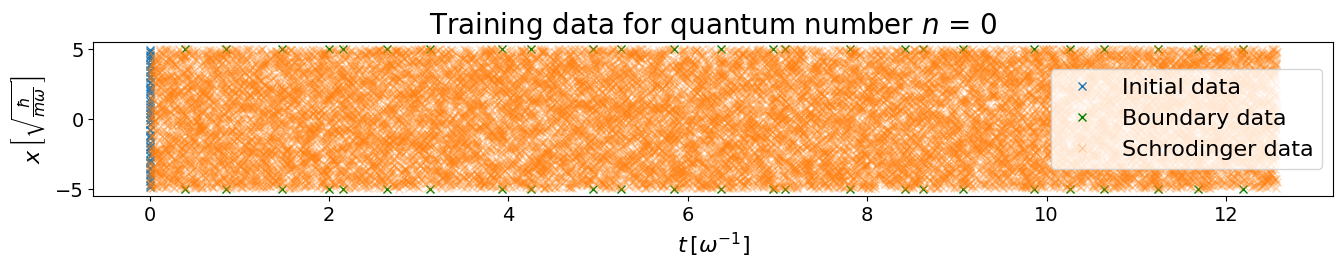

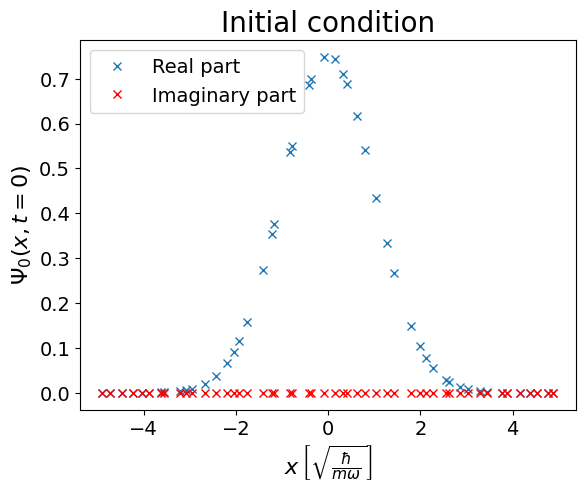

In [25]:
def visualize_imported_data(boundary_vals, initial_vals, schrodinger_vals, shared_data, save_svg=False):
    """
    This function visualizes the imported data from the data_generator.py file.
    The imported data are the boundary, initial and schrodinger data.
    It enables the user to save the figure as a svg file.
    Therefore, set the save_svg parameter to True.

    Parameters
    ----------
    boundary_vals : torch.tensor
        boundary data
    initial_vals : torch.tensor
        initial data
    schrodinger_vals : torch.tensor
        schrodinger data
    shared_data : SharedData
        shared data
    save_svg : bool, optional
        save figure as svg file, by default False
    
    Returns
    -------
    None
        None
    """
    n = shared_data.n
    schr = schrodinger_vals.getall()
    init = initial_vals.getall()
    bound = boundary_vals.getall()

    schrodinger_x = schr[0].cpu()
    schrodinger_t = schr[1].cpu()

    boundary_x = bound[0].cpu()
    boundary_t = bound[1].cpu()

    init_x = init[0].cpu()
    init_t = init[1].cpu()

    %matplotlib inline
    # Plotting Training Data
    fig, ax = plt.subplots(figsize=(16, 2))
    ax.plot(init_t, init_x, 'x', label='Initial data')
    ax.plot(boundary_t, boundary_x, 'x', c='g', label='Boundary data')
    ax.plot(boundary_t, -boundary_x, 'x', c='g')
    ax.plot(schrodinger_t, schrodinger_x, 'x', alpha=0.31, label='Schrodinger data')
    ax.set_title(fr'Training data for quantum number $n$ = {n}', fontsize=20)
    ax.set_ylabel(r"$x\,\left[\sqrt{\frac{\hbar}{m\omega}}\right]$", fontsize=16)
    ax.set_xlabel(r"$t\,[\omega^{-1}]$", fontsize=16)
    ax.tick_params(axis='both', labelsize=14)
    ax.legend(loc='center right', fontsize=16)
    plt.show()

    # Saving SVG if required
    if save_svg:
        fig.savefig(f'Trainingdata_n={n}.svg', format='svg', bbox_inches='tight')

    # Plotting Initial Condition
    x, t, psi = initial.getall()
    fig, ax = plt.subplots()
    ax.plot(x.cpu(), psi[:, 0].cpu(), 'x', label='Real part')
    ax.plot(x.cpu(), psi[:, 1].cpu(), 'x', c='r', label='Imaginary part')
    ax.set_title("Initial condition", fontsize=20)
    ax.set_xlabel(r"$x\,\left[\sqrt{\frac{\hbar}{m\omega}}\right]$", fontsize=16)
    ax.set_ylabel(fr"$Ψ_{n}(x,t=0)$", fontsize=16)
    ax.tick_params(axis='both', labelsize=14)
    ax.legend(fontsize=14, loc='upper left')
    plt.show()

    # Saving SVG if required
    if save_svg:
        fig.savefig(f'Initial_Condition_n={n}.svg', format='svg', bbox_inches='tight')

    pass
visualize_imported_data(boundary, initial, schrodinger, shared_data, save_svg=True)


# Data preperation

In [26]:
def create_training_data(
        boundary_vals, 
        initial_vals, 
        schrodinger_vals,
        num_col_train = 20000,
    ):
    """
    Create training and test data for training procedure.

    This function generates training and test datasets using a subset
    of the boundary values , initial values and the schrodinger values.
    Therefore the following steps need to be done:
    

    Step 1: Data Point Selection
            Select evenly spaced values from the 'schrodinger_vals' tensor:

            - Create a tensor 'all_idx' containing indices between 0 
              and len(schrodinger_vals)-1 to select data points.
            - Create a tensor 'idx_train' containing 'num_t_train'evenly spaced indices 
              between 0 and the length of the 'schrodinger_vals' tensor to select data points.
            - Generate a mask with booleans of len(all_idx) that gives False statements for entries
              that are both in 'all_idx' and in 'idx_train'.
            - Build a tensor 'idx_test' by applying the mask on 'all_idx'.
            - Ensure that the data type of all idx tensors are integer.

    Step 2: Training Data Creation
            - Define 'schrodinger_train'tensor by selecting index values 'idx_train' 
              from 'schrodinger_vals' input tensor.
            - We don't want to make changes to the original data therefore use '.clone().detach()'.
            - Create a dataloader 'schrodinger_train_dl' for the 'schrodinger_train' tensor.
        
    Step 3: Testing Data Creation
            Repeat the procedure of step to by selecting index values 'idx_test'.

    Step 4: Dataset Creation
            - Create datasets train_ds and test_ds by using dictionaries 
              containing "boundary", "initial", "schrodinger" and "schrodinger_dl" entries.
            - Use the getall method in order to extract tensors for the "boundary" and "initial" keys.
              
    Step 5:  Return the created datasets.
    
    Parameters
    ----------
    boundary_vals : Schrodinger_Boundary 
        Object containing boundary values.
    initial_vals : Schrodinger_Initial
        Object containing initial values.
    schrodinger_vals : Schrodinger
        Object containing schrodinger values.
    num_col_train : int
        Number of collocation points.
        
    Returns
    -------
    Dict
        A dictionary containing "boundary," "initial," and "schrodinger" entries for training data.
    Dict
        A dictionary containing "boundary," "initial," and "schrodinger" entries for testing data.
    """
    
    # Step 1: Data Point Selection
    all_idx = torch.arange(0, 20000-1, dtype=torch.int)
    idx_train = torch.linspace(0, 20000-1, num_col_train, dtype=torch.int)
    mask = ~torch.isin(all_idx, idx_train)
    idx_test = all_idx[mask]
    
    # Step 2: Training Data Creation
    schrodinger_train = schrodinger_vals[idx_train]
    schrodinger_train_x = schrodinger_train[0].clone().detach()
    schrodinger_train_t = schrodinger_train[1].clone().detach()
    
    # Step 3: Testing Data Creation
    schrodinger_test = schrodinger_vals[idx_test]
    schrodinger_test_x = schrodinger_test[0].clone().detach()
    schrodinger_test_t = schrodinger_test[1].clone().detach()

    # Step 4: Unpacking Data
    boundary_input_x = boundary_vals.getall()[0].clone().detach()
    boundary_input_t = boundary_vals.getall()[1].clone().detach()
    initial_input_x = initial_vals.getall()[0].clone().detach()
    initial_input_t = initial_vals.getall()[1].clone().detach()
    initial_target = initial_vals.getall()[2].clone().detach()

    # Step 5: Gradient Data 
    boundary_input_x.requires_grad = True
    boundary_input_t.requires_grad = True
    initial_input_x.requires_grad = True
    initial_input_t.requires_grad = True
    initial_target.requires_grad = True

    schrodinger_train_x.requires_grad = True
    schrodinger_train_t.requires_grad = True
    schrodinger_test_x.requires_grad = True  
    schrodinger_test_t.requires_grad = True

    boundary_inputs = [boundary_input_x, boundary_input_t]
    initial_inputs = [initial_input_x, initial_input_t]
    schrodinger_train = [schrodinger_train_x, schrodinger_train_t]
    schrodinger_test = [schrodinger_test_x, schrodinger_test_t]
    
    # Step 4: Dataset Creation
    train_ds = {"boundary": {"inputs": boundary_inputs, "targets": []}, 
                "initial": {"inputs": initial_inputs, "targets": initial_target},
                 "schrodinger": {"inputs": schrodinger_train, "targets": []}}
    test_ds = {"boundary": {"inputs": boundary_inputs, "targets": []}, 
                "initial": {"inputs": initial_inputs, "targets": initial_target},
                 "schrodinger": {"inputs": schrodinger_test, "targets": []}}
    #{"boundary": boundary, "initial": initial_vals.getall(), "schrodinger": schrodinger_test, "schrodinger_dl": schrodinger_test_dl}

    # Step 5: Return the created datasets
    return train_ds, test_ds


# Create PINN model

In [27]:
class PINN(nn.Module):
    """
    Physics-Informed Neural Network (PINN) Class
    
    This class as a subclass of torch.nn.Module defines the architecture of the PINN model. 
    It is designed to use differential equations while incorporating physics-based constraints.
    The process consists of the following steps:
    
    Step 1: Model Initialization
        - Initialize the PINN model as a subclass of nn.Module.

    Step 2: Constructor Definition
        - Build a constructor to configure the model's architecture.
        - Utilize the nn.Linear class from the PyTorch library for defining layers and connections.
        - Initialize the weights of the layers using the Xavier uniform initializer.

    Step 3: Forward Pass Mechanism
        - Define the forward pass mechanism for the model, where input data flows through the layers
          to produce predicted outputs.
       
    """
    def __init__(self):
        """
        Constructor for the PINN class.
        
        Initializes the layers of the neural network:
        - Input layer fc1 taking a tensor with time and space data.
        - Four hidden fully connected layers fc2-fc5 with 100 neurons.
        - Output layer h_real for predicting the real part.
        - Output layer h_imag for predicting the imaginary part.
        
        Parameters
        ----------
        None
            
        Attributes
        ----------
        fc1 : nn.Linear
            First fully connected layer.
        fc2 : nn.Linear
            Second fully connected layer.
        fc3 : nn.Linear
            Third fully connected layer.
        fc4 : nn.Linear
            Fourth fully connected layer.
        fc5 : nn.Linear
            Fifth fully connected layer.
        h_real : nn.Linear
            Output layer for x-coordinate prediction.
        h_imag : nn.Linear
            Output layer for y-coordinate prediction.
        
        Returns
        -------
        None
        
        """
        super(PINN, self).__init__()
        
        # Step 2: Constructor Definition
        self.fc1 = nn.Linear(2,100).to(device)
        torch.nn.init.xavier_uniform_(self.fc1.weight)
        self.fc2 = nn.Linear(100,100).to(device)
        torch.nn.init.xavier_uniform_(self.fc2.weight)
        self.fc3 = nn.Linear(100,100).to(device)
        torch.nn.init.xavier_uniform_(self.fc3.weight)
        self.fc4 = nn.Linear(100,100).to(device)
        torch.nn.init.xavier_uniform_(self.fc4.weight)
        self.fc5 = nn.Linear(100,100).to(device)
        torch.nn.init.xavier_uniform_(self.fc5.weight)
        self.h_real = nn.Linear(100,1).to(device)
        torch.nn.init.xavier_uniform_(self.h_real.weight)
        self.h_imag = nn.Linear(100,1).to(device)
        torch.nn.init.xavier_uniform_(self.h_imag.weight)
        self.optimizer = optim.Adam(self.parameters(), lr=0.00025)
        pass
    
    def forward(self, x):
        """
        Perform a forward pass through the PINN model.
        
        This method defines the forward pass mechanism of the PINN model, where
        the input data X is processed through the layers to produce predicted
        outputs for both real part of the solution (h_real) 
        and imaginary part of the solution (h_imag).
        The following steps are necessary:
        
    Step 1: Pass input through layers with GELU Activation:
        - Pass the input tensor 'X' through the 'fc1' linear layer.
        - Apply the tanh activation function 'torch.tanh' to the output.
        - reply this procedure for the remaining layers

    Step 2: Output Layer for Predicted Coordinates:
        - Compute the predicted real solution by passing the transformed tensor 'x' 
          through the 'h_real' layer.
        - Compute the predicted imaginary solutiun by passing the same transformed tensor 'x' 
          through the 'h_imag' layer.

    Step 3: Return the predicted real and imaginary solution.
        
        Parameters
        ----------
        t : torch.Tensor
            Input data tensor.
            
        Returns
        -------
        Tuple[torch.Tensor, torch.Tensor]
            Predicted real and imaginary solution.
        """

        # Step 1: Forward Pass Mechanism
        x = torch.tanh(self.fc1(x))   
        x = torch.tanh(self.fc2(x))  
        x = torch.tanh(self.fc3(x))  
        x = torch.tanh(self.fc4(x))  
        x = torch.tanh(self.fc5(x))     

        # Step 2: Produce predicted real and imaginary solution using output layers and return them. 
        h_real = self.h_real(x)
        h_imag = self.h_imag(x)

        return h_real, h_imag

# Boundary loss

To constrain the model prediction $h(x,t)$ to be symmetric in space, a boundary loss must be defined.
Boundary Conditions:

*   $h(5,t)=h(-5,t)$ 

*   $h_{x}(5,t)=h_{x}(-5,t)$

Task:

Define the `compute_boundary_loss` function by following the steps stated in the docstring.

In [28]:
def compute_boundary_loss(model, dataset: dict):
    """
    Define the physics-informed loss for the PINN model.
    
    This function calculates the loss used to incorporate the boundary conditions
    into the PINN. The following steps are involved:
    
    Step 1: Data Preparation
        - Unpack 'boundary' from the dataset and enable gradient computation.
        - Create a tensor 'x_bound' containing the value 5 with the same length as 't_bound'.

    Step 2: Model Prediction
        - Predict real and imaginary values at (5, t_bound) and (-5, t_bound) using the neural network model.
        - Concatenate the two input tensors along axis 1.

    Step 3: Gradient Computation
        - Compute the first gradients 'hp_r_x', 'hp_c_x', 'hn_r_x', and 'hn_c_x' 
          with respect to the 'x_bound' tensor using the 'torch.autograd.grad' method.

    Step 4: Difference Calculation
        - Calculate the difference between 'hp_r' and 'hn_r' for real and imaginary parts.
        - Use 'torch.unsqueeze' to add a dimension along the 1 axis.

    Step 5: Derivative Difference Calculation
        - Calculate the difference between 'hp_r_x' and 'hn_r_x' for real and imaginary parts.
        - This time no 'torch.unsqueeze' needed

    Step 6: Residual Calculation
        - Define 'h_err' and 'h_x_err' by adding the squared differences of real and imaginary parts.

    Step 7: Loss Calculation
        - Compute the mean squared error loss for 'h_err' and 'h_x_err' using the 'nn.MSELoss' class.
        - as a target serves a tensor containing zeros. It can be produced using 'torch.zeros_like'
        - Return the combined physics-informed loss as the sum of 'loss_h' and 'loss_h_x'.
    
    Parameters
    ----------
    model : torch.nn.Module
        The physics-informed neural network model.
    dataset : dict
        A dictionary containing "boundary" entries.
        
    Returns
    -------
    torch.Tensor
        The combined (h and h_x) physics-informed loss.
    """
    # Step 1: Data Preparation
    x_bound, t_bound = dataset["boundary"]["inputs"]

    
    # Step 2: Model Prediction
    hp_r, hp_c = model(torch.cat((x_bound, t_bound),1))
    hn_r, hn_c = model(torch.cat((-x_bound, t_bound),1))
    
    # Step 3: Gradient Computation
    hp_r_x = grad(outputs=hp_r, inputs=x_bound, grad_outputs=torch.ones_like(hp_r), create_graph=True)[0]
    hp_c_x = grad(outputs=hp_c, inputs=x_bound, grad_outputs=torch.ones_like(hp_c), create_graph=True)[0]

    hn_r_x = grad(outputs=hn_r, inputs=x_bound, grad_outputs=torch.ones_like(hn_r), create_graph=True)[0]
    hn_c_x = grad(outputs=hn_c, inputs=x_bound, grad_outputs=torch.ones_like(hn_c), create_graph=True)[0]
    
    # Step 4: Difference Calculation
    h_r_diff = torch.unsqueeze(hp_r - hn_r, 1)
    h_c_diff = torch.unsqueeze(hp_c - hn_c, 1)

    # Step 5: Derivative Difference Calculation
    h_rx_diff = hp_r_x - hn_r_x
    h_cx_diff = hp_c_x - hn_c_x

    # Step 6: Residual Calculation
    h_res = h_r_diff**2 + h_c_diff**2
    h_x_res = h_rx_diff**2 + h_cx_diff**2

    # Step 7: Loss Calculation
    mse_loss = nn.MSELoss()

    loss_h = mse_loss(h_res, torch.zeros_like(h_res))
    loss_h_x = mse_loss(h_x_res, torch.zeros_like(h_x_res))

    return loss_h + loss_h_x


# Initial loss

This part is used, to implement the initial state $\psi(x,0)$ of the system, as visualized above.  
Task:  
Define the `compute_boundary_loss` function by following the steps stated in the docstring.

In [29]:
def compute_initial_loss(model, dataset: dict):
    """
    Calculate the loss associated with satisfying the initial conditions for the PINN model.

    This function computes the loss that measures how well the initial conditions are met by the PINN. 
    The dataset containes information about the initial condition.
    The following steps are involved:

    Step 1: Data Preparation
        - Extract 'T_0', 'X_0' and 'H_0' from the training dataset and enable gradient computation.

    Step 2: Model Prediction
        - Use the neural network model to predict the real and imaginary values at (X_0, T_0).
        - Concatenate the two input tensors along axis 1.

    Step 3: Concatenation
        - Combine the real and imaginary parts of the predicted values along axis 1.

    Step 4: Loss Calculation
        - Calculate and return the mean squared error loss between 'H_0' and the concatenated values 'h'.

    Parameters
    ----------
    model : torch.nn.Module
        The physics-informed neural network model.
    train_ds : dict
        A dictionary that includes "initial" entries with "X_0," "T_0," and "H_0."

    Returns
    -------
    torch.Tensor
        The loss quantifying how well the initial conditions are satisfied.
    """
    # Step 1: Data Preparation
    X_0 ,T_0= dataset["initial"]["inputs"]
    H_0 = dataset["initial"]["targets"]

    zeros = torch.zeros((len(X_0),1)).float().to(device)
    # Step 2: Model Prediction
    h_r, h_c = model(torch.cat((X_0, T_0),1))

    # Step 3: Concatenation
    h = torch.cat((h_r, h_c), 1)
    
    # Step 4: Loss Calculation
    mse_loss = nn.MSELoss()
    loss_h_0 = mse_loss(H_0, h)

    return loss_h_0

# Physics-informed Loss

The time dependant Schrodinger Equation describes the time evolution of the quantum mechanic harmonic oscillator:

$i\hbar\frac{\partial}{\partial t}\psi(x,t)=\hat{H} \psi(x,t) $  

After reordering and using the Hamiltonian of the quantum harmonic oscillator, we obtain:

$\left(i\hbar\frac{\partial}{\partial t}-\frac{\hbar^2}{2m}\frac{\partial^2}{\partial x^2}+\frac{m \omega^2}{2}x^2\right) \psi(x,t)=0$ 

However, this equation cannot be directly applied to the `compute_physics_informed_loss` function in its current form.  
This is because the model predicts separate solutions for the real and imaginary parts, labeled as $\psi_r(x,t) $ and $ \psi_i(x,t)$ respectively, instead of a single solution $\psi(x,t)$.  
To implement the equation, first divide it into real and imaginary parts.  
Complete the following tasks:

1. Replace $\psi(x,t)$ with $\psi_r(x,t) + i \psi_i(x,t)$ and insert it into the equation.

2. Split the left side of the equation into its real and imaginary parts.

3. Follow the step-by-step explanation to define the `compute_physics_informed_loss` function and use the  
   results from Task 2 to define the residuals `f_r` and `f_i`.




In [30]:
def potential_scaling_function(t:torch.Tensor, potential_scaling:bool)->torch.Tensor:
    """
    This function defines the potential scaling function.
    
    Parameters
    ----------
    t : torch.Tensor
        The time values.
    potential_scaling : bool
        Whether the potential scaling is set to True of false.
    
    Returns
    -------
    torch.Tensor
        The potential scaling function.
    """
    if potential_scaling==True:
        return torch.where(t < period/2, torch.cos(t/((period)/torch.pi))**2, torch.tensor(0.))
    else: 
        return torch.ones_like(t)

In [35]:
def compute_physics_informed_loss(model, dataset: dict, potential_scaling:bool):
    """
    Calculate the loss for the Schrödinger equation condition in the PINN model.

    This function computes the loss that measures how well the Schrödinger equation condition
    is satisfied by the PINN. The following steps are involved:

    Step 1: Data Preparation
        - Extract the tensor 'X' from the training dataset in "schrodinger" and enable gradient computation.
        - Apply 'clone().detach()' to 'X' to avoid changing the original data.

    Step 2: Tensor Extraction
        - Extract two tensors 't' and 'x' from 'X,' representing the first and second columns of 'X.'
        - Ensure that 't' and 'x' have a shape of (len(X), 1).

    Step 3: Model Prediction
        - Use the neural network model to predict the real and imaginary values at (t, x).
        - Concatenate the two input tensors along axis 1.

    Step 4: Derivative Computation
        - Compute the first derivatives with respect to 't' and the second derivatives with respect to 'x' 
          for both the real and the imaginary part of the solution.

    Step 5: Residuals Definition
        - Define residuals 'f_r' and 'f_i' containing the Schrödinger equation condition: 
          ih_t + 0.5h_xx + h(|h|^2) = 0.

    Step 6: Residual Calculation
        - Define a residual 'f' by computing the Euclidean norm from 'f_r' and 'f_i.'

    Step 7: Loss Calculation
        - Calculate and return the mean squared error loss between 'f' and zeros.

    Parameters
    ----------
    model : torch.nn.Module
        The physics-informed neural network model.
    train_ds : dict
        A dictionary containing "schrodinger" entries.
        
    Returns
    -------
    torch.Tensor
        The loss quantifying how well the Schrödinger equation condition is satisfied.
    """
    # Step 1: Data Preparation
    x, t = dataset["schrodinger"]["inputs"]

    # Step 3: Model Prediction
    h_r, h_i = model(torch.cat((x, t),1))

    # Step 4: Derivative Computation
    h_x_r = grad(outputs=h_r, inputs=x, grad_outputs=torch.ones_like(h_r), create_graph=True)[0]
    h_xx_r = grad(outputs=h_x_r, inputs=x, grad_outputs=torch.ones_like(h_x_r), create_graph=True)[0]
    h_t_r = grad(outputs=h_r, inputs=t, grad_outputs=torch.ones_like(h_r), create_graph=True)[0]

    h_x_i = grad(outputs=h_i, inputs=x, grad_outputs=torch.ones_like(h_i), create_graph=True)[0]
    h_xx_i = grad(outputs=h_x_i, inputs=x, grad_outputs=torch.ones_like(h_x_i), create_graph=True)[0]
    h_t_i = grad(outputs=h_i, inputs=t, grad_outputs=torch.ones_like(h_i), create_graph=True)[0]  

    # Step 5: Residuals Definition
    f_r = -(h_t_i) + (0.5 * h_xx_r) - (potential_scaling_function(t, potential_scaling)*(0.5*x**2)*h_r)
    f_i = (h_t_r) + (0.5 * h_xx_i) - (potential_scaling_function(t, potential_scaling)*(0.5*x**2)*h_i) 

    # Step 6: Residual Calculation
    f = torch.sqrt((f_r**2) + (f_i**2))

    # Step 7: Loss Calculation
    mse_loss = nn.MSELoss()
    loss_f = mse_loss(f, torch.zeros_like(f))


    
    return loss_f

# Total loss

In [36]:
def compute_total_loss(model, dataset: dict, potential_scaling:bool):
    """
    Define the total loss for the physics-informed neural network.

    This function computes the total loss for the PINN model by combining three
    different components:  boundary, inital and physics-informed loss.
    The following steps are involved:

    Step 1: Loss Calculation
        - Determine the boundary, inital and physics loss using the corresponding functions.

    Step 2: Total Loss Combination
        - Return the combined total loss as the sum of 'data_loss' and 'physics_loss' (if activated).


    Parameters
    ----------
    model : torch.nn.Module
        The physics-informed neural network model.
    dataset : dict
        A dictionary containing "inputs", "targets_x", "targets_y", and "t_col" entries.

    Returns
    -------
    torch.Tensor
        The combined total loss considering data and physics constraints.
    """
    # Step 1: Loss Calculation
    initial_loss = compute_initial_loss(model, dataset)
    boundary_loss = compute_boundary_loss(model, dataset)
    physics_loss = compute_physics_informed_loss(model, dataset, potential_scaling)

    # Step 3: Total Loss Combination
    total_loss = initial_loss + physics_loss + boundary_loss

    return total_loss


# Execution function

In [37]:
def execute(
        model,
        train_ds: dict,
        test_ds: dict,
        lr = 0.00025, 
        num_epochs = 2000,
        num_batches = 25,
        potential_scaling = False,
    ):
    """
    Execute the training procedure for a physics-informed neural network model.

    This function trains the model using specified hyperparameters and returns relevant data.
    The process involves the following steps:

    Step 1: Optimizer Initialization
            The optimizer is used to update the model's parameters during training. Therefore:
            - Initialize the optimizer, Adam with the model parameters.
            - Configure it with a specified learning rate 'lr'.
            More informations on the Adam optimizer can be found here:
            (see [ADAM](https://pytorch.org/docs/stable/generated/torch.optim.Adam.html))
    
    Step 2: Lists Initialization
            To store the values of the models loss during the training process:
            - Initialize the lists 'train_loss_evolution' and 'test_loss_evolution'. 

    Step 3: Training Loop Setup
            Set up a training loop that will run for a specified number of epochs ('num_epochs'). 

        Step 4: Epoch Loss Tracking:
                - Calculate the train and test loss using the 'compute_total_loss' function.
                - Append the current train and test loss values to the appropriated lists.

        Step 5: Permutation of Training Data:
                - Create a list 'permutations' containing a random permutation of the indices of the training data.
                - Split the indices into 'num_batches' batches using the 'torch.tensor_split' method.

        Step 6: Nested Batch Training Loop Setup
                Set up a nested batch training loop that will run for a specified number of batches ('num_batches').

            Step 7: Data Preparation
                    - Initialize an empty dictionary 'train_batch_ds'.
                    - Split the training data into batches using the 'torch.tensor_split' method.
                    - Add the current batch to the dictionary 'train_batch_ds'.


            Step 8: Batch Training
                    - Reset the gradients of the optimizer using the 'zero_grad' method.
                    - Calculate the loss using the 'compute_total_loss' function.
                    - Backpropagate the loss using the 'backward' method.
                    - Update the model parameters using the 'step' method.

        Step 9: Print Progress
                - Print current epoch and losses

    Step 10: Data Return
            Once the training loop is completed, return the lists you have initialized in Step 2.

    Parameters
    ----------
    model : torch.nn.Module
        The neural network model to be trained and evaluated.
    train_ds : dict
        A dictionary containing initial, boundary and schrodinger training data.
    test_ds : dict
        A dictionary containing initial, boundary and schrodinger testing data.
    lr : float, optional
        Learning rate for the optimizer. Default is 0.00025.
    num_epochs : int, optional
        Number of epochs to train the model. Default is 2000.
    num_batches : int, optional
        Number of batches to split the training data into. Default is 25.
    potential_scaling : bool, optional
        Whether to use the potential scaling or not. Default is False.


    Returns
    -------
    train_loss_evolution : list
        A list containing train loss values during training.
    test_loss_evolution : list
        A list containing test loss values during training
    """    

    # Step 1: Optimizer Initialization
    optimizer = optim.Adam(model.parameters(), lr=lr,)  # Include weight_decay in the optimizer

    # Step 2: Lists Initialization
    train_loss_evolution = []
    test_loss_evolution = []

    # Define Loading Bar
    loading_bar = trange(1, num_epochs + 1)


    # Step 3: Training Loop Setup
    for epoch in loading_bar:
        # Step 4: Epoch Loss Tracking
        train_loss = compute_total_loss(model, train_ds, potential_scaling)
        test_loss = compute_total_loss(model, test_ds, potential_scaling)
        test_loss_evolution.append(float(test_loss))
        train_loss_evolution.append(float(train_loss))

        # Step 5: Permutation of Training Data
        permutations = torch.randperm(min(train_ds["schrodinger"]["inputs"][0].shape[0], 
                                        train_ds["initial"]["inputs"][0].shape[0], 
                                        train_ds["boundary"]["inputs"][0].shape[0]))
        permutations = torch.tensor_split(permutations, num_batches)

        # Step 6: Nested Batch Training Loop Setup
        for i in range(len(permutations)):
            # Step 7: Data Preparation
            train_batch_ds = {"boundary": {"inputs": [], "targets": []}, 
                            "initial": {"inputs": [], "targets": []},
                            "schrodinger": {"inputs": [], "targets": []}}

            perm_init_x = torch.tensor_split(train_ds["initial"]["inputs"][0], num_batches)
            perm_init_t = torch.tensor_split(train_ds["initial"]["inputs"][1], num_batches)
            train_batch_ds["initial"]["inputs"] = [perm_init_x[i], perm_init_t[i]]
            
            perm_init_psi = torch.tensor_split(train_ds["initial"]["targets"], num_batches)
            train_batch_ds["initial"]["targets"] = perm_init_psi[i]
        
            perm_bound_x = torch.tensor_split(train_ds["boundary"]["inputs"][0], num_batches)
            perm_bound_t = torch.tensor_split(train_ds["boundary"]["inputs"][1], num_batches)
            train_batch_ds["boundary"]["inputs"] = [perm_bound_x[i], perm_bound_t[i]]
        
            perm_schrodinger_x = torch.tensor_split(train_ds["schrodinger"]["inputs"][0], num_batches)
            perm_schrodinger_t = torch.tensor_split(train_ds["schrodinger"]["inputs"][1], num_batches)
            train_batch_ds["schrodinger"]["inputs"] = [perm_schrodinger_x[i], perm_schrodinger_t[i]]

        
            # Step 8: Batch Training
            optimizer.zero_grad()
            train_loss = compute_total_loss(model, train_batch_ds, potential_scaling)
            train_loss.backward()
            optimizer.step()

        # Step 9: Print Progress
        loading_bar.set_description(f"Epoch: {epoch}")
        loading_bar.set_postfix({"Test Loss": test_loss.item(), "Train Loss": train_loss.item()})
        

    # Step 10: Data Return
    return train_loss_evolution, test_loss_evolution

# Execution task: Verification
Execute Training and Visualize  
    Execute the training for the following set of (hyper)parameters.  
    Plot the loss evolution during training and the final prediction of the model (after training).
    Compare the final predictions to the true solution of the trajectory. 
        
- Use __20000 collocation training points__ for data generation
- Train over  $n_\text{epochs} =2000$ __epochs__



In [38]:
# Step 1: Initialize the model by calling the PINN class created earlier.
model = PINN()

# Step 2: Generate training and test datasets by calling the 'create_training_data' function.
train_ds, test_ds = create_training_data(boundary, 
        initial, 
        schrodinger,
        num_col_train=20000,
        )
# Step 3: Execute the training and testing of the model.
train_loss_evolution, test_loss_evolution = execute(
    model,
    test_ds=test_ds,
    train_ds=train_ds,
    num_epochs=20,
    num_batches=25,
    potential_scaling=True,
)

Epoch: 20: 100%|██████████| 20/20 [00:29<00:00,  1.49s/it, Test Loss=nan, Train Loss=0.00463]


In [39]:
def visualize_training(train_loss_evolution, test_loss_evolution):
    """
    Visualize the evolution of the loss during training.

    This function plots the evolution of the loss during training.
    The following steps are involved:


    Parameters
    ----------
    train_loss_evolution : list
        A list containing train loss values during training.
    test_loss_evolution : list
        A list containing test loss values during training.

    Returns
    -------
    None
    """
    # Step 1: Create a figure and axis
    fig, ax = plt.subplots()

    # Add labels and a legend
    ax.plot(np.linspace(0, len(train_loss_evolution), len(train_loss_evolution)), train_loss_evolution, c='r', label='Training loss')
    ax.plot(np.linspace(0, len(test_loss_evolution), len(test_loss_evolution)), test_loss_evolution, c='g', label='Test loss')
    ax.legend()
    ax.set_title('Loss Evolution')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_yscale('log')  # Set y-axis to logarithmic scale

    # Show the plot
    plt.show()


# Result plotting



In [40]:
def visualize_solution(model, period, potential_scaling, n, save_svg=False):
    """
    Visualize the solution of the Schrödinger equation.

    This function visualizes the solution of the Schrödinger equation by using the
    neural network model.
    It enables the User to visualize the solution in different ways:
    - Contour plot of the norm of the solution.
    - Contour plot of the real part of the solution.
    - Contour plot of the imaginary part of the solution.
    - 3D surface plot of the solution.
    - Cross-section of the solution at t=period/2.

    The Contour plots can be saved as SVG files by setting 'save_svg' to True.
    The Name of the SVG files can be customized by setting 'n' and 'potential_scaling' to the desired value.

    Parameters
    ----------
    model : torch.nn.Module
        The physics-informed neural network model.
    period : float
        The period time of the wavefunction.
    potential_scaling : bool
        Whether the potential scaling is set to True of false.
    n : int
        The n-th solution of the Schrodinger equation.
    save_svg : bool, optional
        Whether to save the contour plots as SVG files. Default is False.
    
    Returns
    -------
    None
       
    """
    result = "True" if potential_scaling else "False"
    %matplotlib inline
    # Create position and time arrays
    x = np.linspace(-5,5,300)
    t = np.linspace(0,period,300)

    # Create a meshgrid
    X,T = np.meshgrid(x,t)

    # Create a combined input tensor
    _X = torch.tensor(np.dstack((X,T))).float().to(device)

    # Compute the predicted real and imaginary parts of the solution
    h_r_hat, h_i_hat = model(_X)

    # Detach the tensors from the computational graph
    h_r_hat = h_r_hat.to('cpu').detach()
    h_i_hat = h_i_hat.to('cpu').detach()

    # Combine the real and imaginary parts
    h_hat = torch.cat((h_r_hat, h_i_hat),2)

    # Compute the norm of the solution
    h_norm = np.sqrt((h_hat[:,:,0] ** 2) + (h_hat[:,:,1] ** 2))

    # Plot the norm of the solution
    fig = plt.figure(figsize=(16, 2))
    ax = plt.axes()

    cf = ax.contourf(T,X,h_norm, 30)
    plt.colorbar(cf)
    plt.title(r"$|Ψ(x,t)|$")
    plt.ylabel(r"x$\left[\sqrt{\frac{\hbar}{m\omega}}\right]$")
    plt.xlabel(r"$t[\omega^{-1}]$")
    plt.show()
    # Save the figure as an SVG file
    if save_svg:
        fig.savefig(f'Contour_norm_{n}_{result}.svg', format='svg', bbox_inches='tight')

    # Plot the real part of the solution
    fig = plt.figure(figsize=(16, 2))
    ax = plt.axes()

    cf = ax.contourf(T,X,h_hat[:,:,0], 60, cmap='RdBu')
    plt.colorbar(cf)
    plt.title(r"$Ψ_r(x,t)$")
    plt.ylabel(r"x$\left[\sqrt{\frac{\hbar}{m\omega}}\right]$")
    plt.xlabel(r"$t[\omega^{-1}]$")
    plt.show()
    # Save the figure as an SVG file
    if save_svg:
        fig.savefig(f'Contour_Real_{n}_{result}.svg', format='svg', bbox_inches='tight')

    # Plot the imaginary part of the solution
    fig = plt.figure(figsize=(16, 2))
    ax = plt.axes()

    cf = ax.contourf(T,X,h_hat[:,:,1], 60, cmap='RdBu')
    plt.colorbar(cf)
    plt.title(r"$Ψ_i(x,t)$")
    plt.ylabel(r"x$\left[\sqrt{\frac{\hbar}{m\omega}}\right]$")
    plt.xlabel(r"$t[\omega^{-1}]$")
    plt.show()
    # Save the figure as an SVG file
    if save_svg:
        fig.savefig(f'Contour_Imag_{n}_{result}.svg', format='svg', bbox_inches='tight')

    # Plot the 3D surface of the solution
    fig = plt.figure()
    ax = plt.axes(projection='3d')
    ax.set_xlabel(r"$t[\omega^{-1}]$")
    ax.set_ylabel(r"x$\left[\sqrt{\frac{\hbar}{m\omega}}\right]$")
    ax.set_zlabel(r"$|Ψ(x,t)|$")
    ax.plot_wireframe(T, X, h_norm)
    #ax.view_init(45, 35)
    plt.show()

    # Plot a cross-section of the solution at t=period/2
    x_slice = x[:]
    h_slice = h_norm[150,:]
    plt.plot(x_slice,h_slice)
    plt.title('Solution Cross-section at t=period/2')
    plt.xlabel(r"x$\left[\sqrt{\frac{\hbar}{m\omega}}\right]$")
    plt.ylabel(r"$|Ψ(x,t)|$")
    plt.show()

    pass

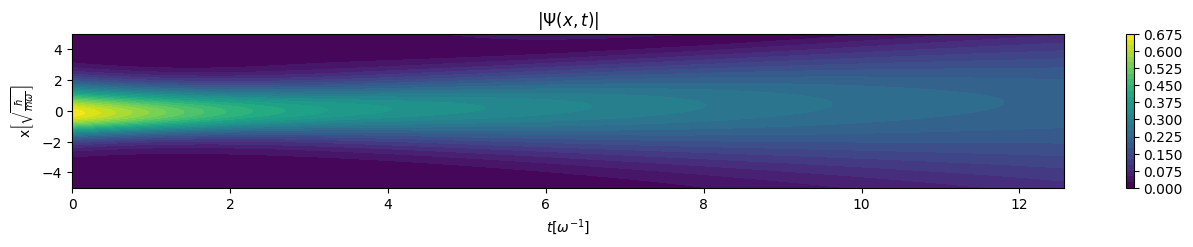

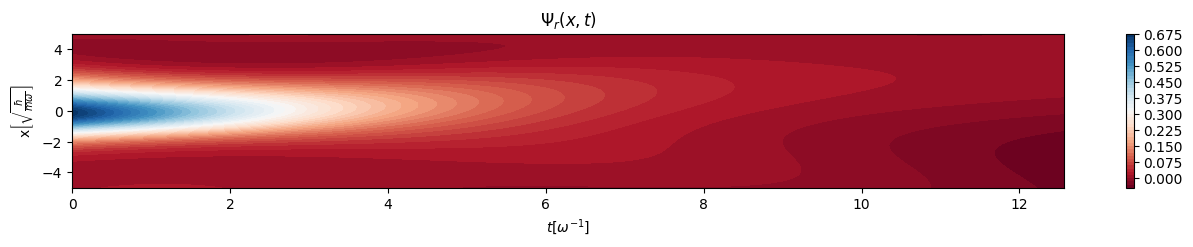

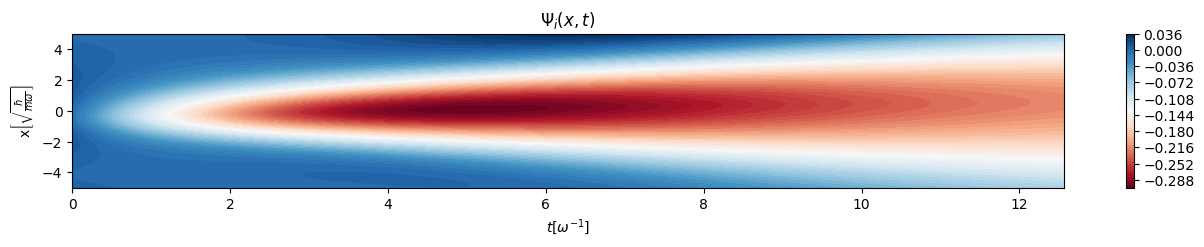

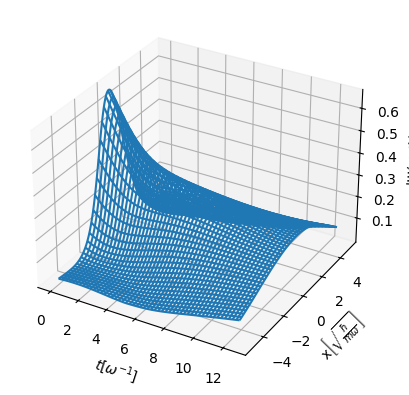

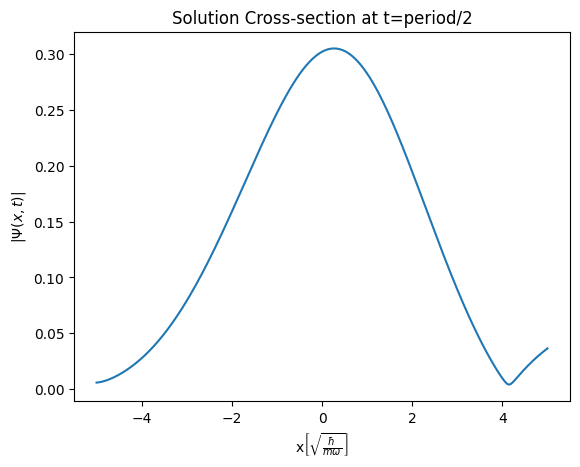

In [41]:
visualize_solution(model, period, potential_scaling=True, n=shared_data.n, save_svg=True)

# Result Animation

In [46]:
def AnimationPreparator(num_frames, n, period):
    """
    This function prepares the data for the animation of the solution of the Schrödinger equation.

    The following steps are involved:
    
    Step 1: Data Preparation
            - Create a tensor 'X' containing 100 evenly spaced values between -5 and 5.
            - Create a tensor 'T' containing num_frames evenly spaced values between 0 and 'period'.
    
    Step 2: List Initialization
            - Initialize the lists 'predictions_list_r', 'predictions_list_i' and 'predictions_list'.

    Step 3: loop over the frames
            - Set up a loop that will run for a specified number of frames ('num_frames').
            In each iteration:
                - Create a tensor 'T_i' containing the current time value repeated 100 times.
                - Use the neural network model to predict the real and imaginary values at (X, T_i).
                - Append the predicted real and imaginary values to the appropriate lists.

    Step 4: Concatenation
            - Concatenate the predicted real and imaginary values along axis 0 to obtain the full solution.
            - Determine the minimum and maximum values of the solution to set the colorbar limits.
    
    Step 5: Return the prepared data.

    Parameters
    ----------
    num_frames : int
        The number of frames to generate.
    n : int
        The number of points to generate.
    period : float
        The period of the potential.
    
    Returns
    -------
    predictions_list : List
        A list containing the norm solution.
    predictions_list_r : List
        A list containing the real part of the solution.
    predictions_list_i : List  
        A list containing the imaginary part of the solution.
    psi_min : float
        The minimum value of the solution.
    psi_max : float
        The maximum value of the solution.
    
    """
    # Step 1: Data Preparation
    X = torch.linspace(-5,5,100).reshape(-1,1).float().to(device)
    T = torch.linspace(0,period, num_frames).reshape(-1,1).float().to(device)

    # Step 2: List Initialization
    predictions_list_r = []
    predictions_list_i = []
    predcitions_list = []
    
    # Step 3: loop over the frames
    for i in range(num_frames):
        T_i = T[i,:].repeat(100,1)
        Ψf_r, Ψf_i = model(torch.cat((X, T_i),1))
        Ψf_r = Ψf_r.cpu()
        Ψf_i = Ψf_i.cpu()
        Ψf = torch.sqrt((Ψf_r ** 2) + (Ψf_i ** 2)).cpu()
        predictions_list_r.append(Ψf_r)
        predictions_list_i.append(Ψf_i)
        predcitions_list.append(Ψf)

    # Step 4: Concatenation
    all_predictions_r = torch.cat(predictions_list_r,0)
    all_predictions_i = torch.cat(predictions_list_i,0)
    all_predictions = torch.cat(predcitions_list,0)
    psi_min = min(all_predictions_r.min(), all_predictions_i.min(), all_predictions.min()).squeeze().item()  # Convert psi_min to a float
    psi_max = max(all_predictions_r.max(), all_predictions_i.max(), all_predictions.max()).squeeze().item()  # Convert psi_max to a float

    # Step 5: Return the prepared data
    return predcitions_list, predictions_list_r, predictions_list_i, psi_min, psi_max


In [47]:
predcitions_list, predictions_list_r, predictions_list_i, psi_min, psi_max = AnimationPreparator(num_frames = 150, 
                                                                                                n=shared_data.n, 
                                                                                                period=shared_data.period)

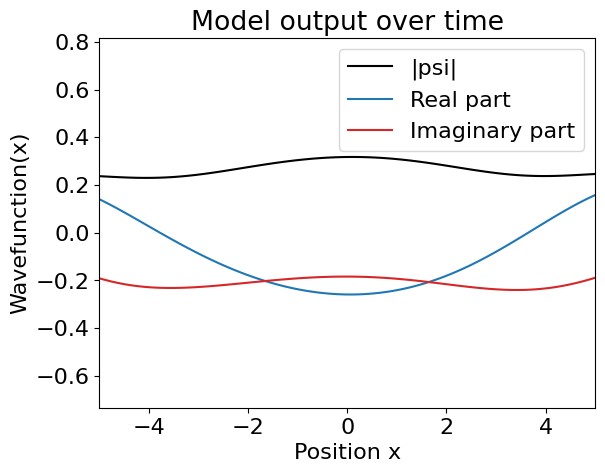

In [48]:
animator = AnimationGenerator(predcitions_list, 
                              predictions_list_r, 
                              predictions_list_i,
                              psi_min,
                              psi_max,)
animator.create_animation('./groundstate.mp4', frames=150, fps=30)

# Execution task 4: Energy Eigenvalues
The PINN model can now predict the temporal evolution of the wave function over a period.  
We will now test whether the energy of the corresponding predicted wave function is consistent with the theory.  
To accomplish this, we begin with the eigenvalue equation of the Hamiltonian.  <br>

$\hat{H}| \psi_n \rangle = E_n  | \psi_n \rangle$  

We multiply both sides with the Bra vector $\langle \psi_n |$ to it:  

$\langle \psi_n| \hat{H} | \psi_n \rangle = E_n \langle \psi_n | \psi_n \rangle$  

We can now evaluate the integral in position space and solve for the energy eigenvalue.  
Let's also denote both integrals with $I_1$ and $I_2$, so that we can treat them each at a time:

$E_n = \underbrace{\left(\int_{-\infty}^{\infty} \psi_n^*(x,t)\cdot \hat{H}\cdot \psi_n(x,t) \,dx\right)}_{1}/\underbrace{\left(\int_{-\infty}^{\infty}\psi_n^*(x,t)\cdot \psi_n(x,t)\,dx\right)}_{2}$

Writing out the Hamiltonian in integral $I_1$ we obtain:

$I_1=\int_{-\infty}^{\infty} \psi_n^*(x,t)\cdot\left(\frac{\hat{p}^2}{2m}+\frac{m \omega^2}{2}x^2\right)\cdot \psi_n(x,t) \,dx$

The integral can be divided into two parts, named $I_{1a}$ and $I_{1b}$.

$I_1=\underbrace{\frac{1}{2m}\int_{-\infty}^{\infty} \psi_n^*(x,t)\cdot\hat{p}^2\psi_n(x,t)\,dx}_{I_{1a}} + \underbrace{\frac{m \omega^2}{2}\int_{-\infty}^{\infty} \psi_n^*(x,t)\cdot\psi_n(x,t)\cdot x^2 \,dx}_{I_{1b}}$

Integral $I_{1b}$ can be further simplified, since $\psi_n^*(x,t)\cdot\psi_n(x,t)=|\psi_n(x,t)|^2$:

$I_{1b}=\frac{m \omega^2}{2}\int_{-\infty}^{\infty} |\psi_n(x,t)|^2\cdot x^2 \,dx$

After reordering and combining everything, we end up with:

$E_n = \frac{\overbrace{\frac{m \omega^2}{2}\int_{-\infty}^{\infty} |\psi_n(x,t)|^2\cdot x^2 \,dx}^{I_{1b}} + \overbrace{\frac{1}{2m}\int_{-\infty}^{\infty} \psi_n^*(x,t)\cdot\hat{p}^2\psi_n(x,t) \,dx}^{I_{1a}} }{\underbrace{\left(\int_{-\infty}^{\infty}|\psi_n(x,t)|^2,dx\right)}_{I_2}}$
___
4. Energy Eigenvalues:  

   However, we cannot directly apply this equation to our model in this form.  
   Because, the model prediction is limited to the $[-5,5]$ in space.  
   Additionally, the model provides separate solutions for the real and imaginary parts of $\psi$, rather than a single solution.  
   Therefore complete the following Tasks: 
   <br><br>

   1. Split up the right side of the equation, into a real and an imaginary part.  
      __Hint__: Integral $I_{1b}$ and $I_2$ are already purely real, so don't waste your time on them.
   <br><br>

   2. Implement a function called `compute_momentum_squared`  
      that returns the second derivative of the real and imaginary parts of the models' prediction.
      <br><br>

   3. Implement a function called `compute_energy_eigenvalue`  
      that returns a list containing a number of `n_time_steps` Energy values between `t=0` and `t=period`.  
      __hint__: Set $ m =1 $, $\hbar =1$ and $\omega =1$  
      __hint__: To calculate an integral, use the torch command `torch.trapz`.
      <br><br>

   4. Plot the real and imaginary parts of the energy eigenvalue over time  
      and explain the result in the evaluation.


In [20]:
def compute_momentum_squared(model, x, t):
    """
    Calculate the momentum squared of the wavefunction.

    This function computes the momentum squared of the wavefunction by using the
    neural network model.

    Parameters
    ----------
    model : torch.nn.Module
        The physics-informed neural network model.
    x : torch.Tensor
        The x values.
    t : torch.Tensor
        The t values.
    
    Returns
    -------
    torch.Tensor
        The second derivative of the wavefunction with respect to x.
    """
    # Step 1: Model Prediction
    h_r, h_i = model(torch.cat((x.unsqueeze(1), t.unsqueeze(1)),1))

    # Step 2: Derivative Computation
    h_x_r = grad(outputs=h_r, inputs=x, grad_outputs=torch.ones_like(h_r), create_graph=True)[0]
    h_xx_r = grad(outputs=h_x_r, inputs=x, grad_outputs=torch.ones_like(h_x_r), create_graph=True)[0]

    h_x_i = grad(outputs=h_i, inputs=x, grad_outputs=torch.ones_like(h_i), create_graph=True)[0]
    h_xx_i = grad(outputs=h_x_i, inputs=x, grad_outputs=torch.ones_like(h_x_i), create_graph=True)[0]
    p2_h_r = -h_xx_r
    p2_h_i = -h_xx_i
    return p2_h_r, p2_h_i

In [21]:
def compute_energy_eigenvalue(model, compute_momentum_squared):
    """
    This function computes the energy eigenvalues of the Schrödinger equation.

    parameters
    ----------
    model : torch.nn.Module
        The physics-informed neural network model.
    compute_momentum_squared : function
        A function that computes the momentum squared of the model.
    
    Returns
    -------
    energy_eigenvalues_real : list
        The real part of the energy eigenvalues.
    energy_eigenvalues_imag : list
        The imaginary part of the energy eigenvalues.
    """
    # Step 1: Data Preparation
    x = torch.linspace(-5,5,1000)
    t = torch.ones_like(x)
    n_time_steps = 100

    # Step 2: Gradient Requirement
    x.requires_grad = True
    t.requires_grad = True

    # Step 3: List Initialization
    energy_eigenvalues_real = []
    energy_eigenvalues_imag = []


    for i in range(n_time_steps):
        # Step 4: time Initialization
        time = i/100*period
        t = torch.ones_like(x)*time

        # Step 5: Model Prediction
        #h_f_xx_r, h_f_xx_i = compute_momentum_squared(model, x, t)
        p2_h_r, p2_h_i = compute_momentum_squared(model, x, t)
        h_r, h_i = model(torch.cat((x.unsqueeze(1), t.unsqueeze(1)),1))

        # Step 6: Integral Calculation
        inside_integral_2= (h_r**2 + h_i**2).squeeze(1)
        integral_2 = torch.trapz(inside_integral_2, x, dim=0)

        inside_integral_1_real = (h_r**2 +h_i**2).squeeze(1) * x**2/2 + 0.5*(h_r.squeeze(1)*p2_h_r + h_i.squeeze(1)*p2_h_i)
        integral_1_real = torch.trapz(inside_integral_1_real, x, dim=0)
        energy_eigenvalue_real = integral_1_real/integral_2

        inside_integral_1_imag = + 0.5*(h_i.squeeze(1)*p2_h_r - h_r.squeeze(1)*p2_h_i)
        integral_1_imag = torch.trapz(inside_integral_1_imag, x, dim=0)
        energy_eigenvalue_imag = integral_1_imag/integral_2

        # Step 7: Array Filling
        energy_eigenvalues_real.append(energy_eigenvalue_real.detach().numpy().astype(float))
        energy_eigenvalues_imag.append(energy_eigenvalue_imag.detach().numpy().astype(float))

    return energy_eigenvalues_real, energy_eigenvalues_imag



0.5030112916231155 2.569248906638677e-06


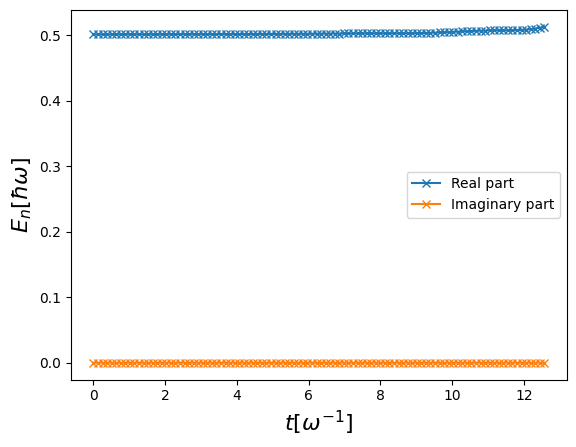

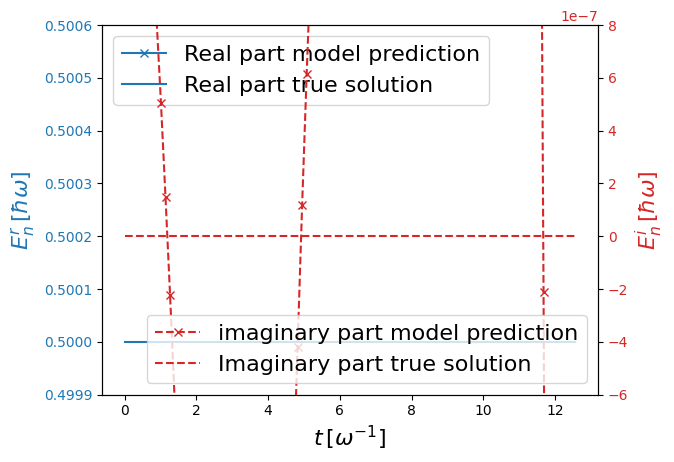

In [23]:
energy_eigenvalues_real, energy_eigenvalues_imag = compute_energy_eigenvalue(model, compute_momentum_squared)

# Compute and print the mean of the energy eigenvalues
real_part = 0
imaginary_part = 0
for i in range(100):
    real_part += energy_eigenvalues_real[i]
    imaginary_part += energy_eigenvalues_imag[i]
print(real_part/100, imaginary_part/100)

%matplotlib inline
t = np.linspace(0, period, 100)
fig, ax = plt.subplots()

ax.plot(t, energy_eigenvalues_real, label='Real part', marker='x')
ax.plot(t, energy_eigenvalues_imag, label='Imaginary part', marker='x')

ax.set_xlabel(r"$t[\omega^{-1}]$", fontsize=16)
ax.set_ylabel(r'$E_n[\hbar\omega$]', fontsize=16)
ax.legend()

plt.show()
fig.savefig(f'Energie_eigenvalue_{shared_data.n}.svg', format='svg', bbox_inches='tight')

fig, ax1 = plt.subplots()

# Plotting real part on the left side
ax1.plot(t, energy_eigenvalues_real, label='Real part model prediction', marker='x', color='tab:blue')
ax1.plot(t, 0.5*np.ones_like(t), label='Real part true solution', color='tab:blue')
ax1.set_xlabel(r"$t\,[\omega^{-1}]$", fontsize=16)
ax1.set_ylabel(r'$E_n^r\,[\hbar\omega]$', fontsize=16, color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.legend(loc='upper left', fontsize=16)
# Setting y-axis limits for ax1
ax1.set_ylim(0.4999, 0.5006)

# Creating a twin Axes for the imaginary part on the right side
ax2 = ax1.twinx()
ax2.plot(t, energy_eigenvalues_imag, label='imaginary part model prediction', marker='x', linestyle='--', color='tab:red')
ax2.plot(t, np.zeros_like(t), label='Imaginary part true solution', linestyle='--', color='tab:red')
ax2.set_ylabel(r'$E_n^i\,[\hbar\omega]$', fontsize=16, color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')
ax1.legend(loc='upper left', fontsize=16)
ax2.legend(loc='lower right', fontsize=16)
# Setting y-axis limits for ax2
ax2.set_ylim(-6e-7, 8e-7)

plt.show()

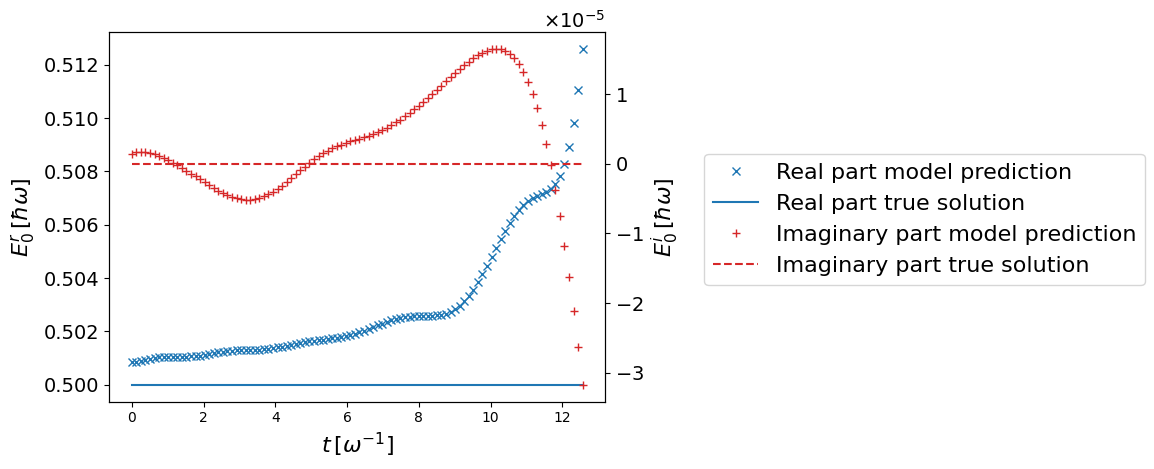

In [24]:
from matplotlib.ticker import ScalarFormatter
fig, ax1 = plt.subplots()

# Plotting real part on the left side
line1, = ax1.plot(t, energy_eigenvalues_real, label='Real part model prediction', marker='x', linestyle='None', color='tab:blue')
line2, = ax1.plot(t, 0.5 * np.ones_like(t), label='Real part true solution', color='tab:blue')
ax1.set_xlabel(r"$t\,[\omega^{-1}]$", fontsize=16)
ax1.set_ylabel(rf'$E_{shared_data.n}^r\,[\hbar\omega]$', fontsize=16)
ax1.tick_params(axis='y', labelsize=14)
ax1.legend(loc='upper left', fontsize=16)
# Setting y-axis limits for ax1
#ax1.set_ylim(0.4999, 0.5006)

# Creating a twin Axes for the imaginary part on the right side
ax2 = ax1.twinx()
line3, = ax2.plot(t, energy_eigenvalues_imag, label='Imaginary part model prediction', marker='+', linestyle='None', color='tab:red')
line4, = ax2.plot(t, np.zeros_like(t), label='Imaginary part true solution', linestyle='--', color='tab:red')
ax2.set_ylabel(rf'$E_{shared_data.n}^i\,[\hbar\omega]$', fontsize=16, )#color='tab:red')
ax2.tick_params(axis='y', labelsize=14)
#ax2.legend(loc='lower right', fontsize=16)
# Setting y-axis limits for ax2
#ax2.set_ylim(-6e-7, 12e-7)

# Combine lines and labels for a single legend
lines = [line1, line2, line3, line4]
labels = [line.get_label() for line in lines]

# Placing a single legend outside the frame
ax1.legend(lines, labels, loc='upper left', fontsize=16, bbox_to_anchor=(1.2, 0.67), borderaxespad=0.)

# Set scalar formatter with increased font size for y-axis ticks
ax2.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax2.yaxis.get_major_formatter().set_powerlimits((0, 1))
ax2.yaxis.offsetText.set_fontsize(14)

plt.show()
fig.savefig(f'Energie_eigenvalue_{shared_data.n}.svg', format='svg', bbox_inches='tight')

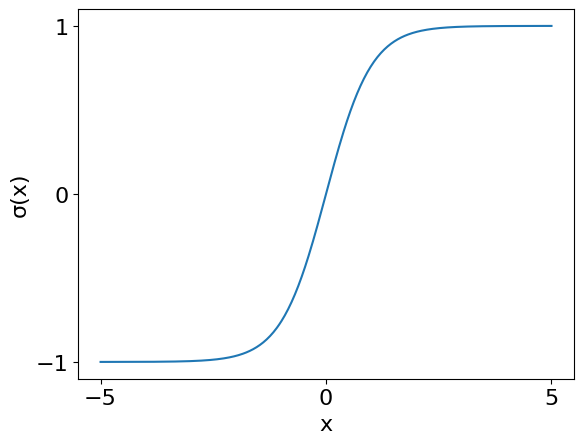

In [53]:
import matplotlib.pyplot as plt
import numpy as np

# Create a range of x values
x = np.linspace(-5, 5, 400)

# Calculate the corresponding y values for the sigmoid function
y = np.tanh(x)

# Create a figure and axis
fig, ax = plt.subplots()
plt.rcParams.update({'font.size': 16})  # Set font size

ax.plot(x, y)

# Adding labels and title
ax.set_xlabel('x')
ax.set_ylabel('σ(x)')

ax.set_xticks([-5, 0, 5])
ax.set_yticks([-1, 0, 1])
#save figure  
fig.savefig(f'tanh.svg', format='svg', bbox_inches='tight')

# Show plot
plt.show()

# Execution task 5: Diminishing Potential 
5. Diminishing Potential  
  
    Now we want to explore how the wave function will behave in a diminishing potential.  
    This happens in 3 Steps:

    1. Implement a function called `potential_scaling_function` that behaves like: $
        A(t) = 
        \begin{cases} 
            \cos^2(t) & \text{if } t < \frac{\text{{period}}}{2} \\
            0 & \text{otherwise}
        \end{cases}
        $
    <br><br>

    2. Implement the function at the right spot into the `compute_physics_informed_loss` function.  
    <br><br>

    3. Execute the training using the same settings as before, but limit the number of epochs to `num_epochs`$=300$.  
       Plot the result using the `visualize_solution` function and save the contour plots for an evaluation.

In [54]:
def potential_scaling_function(t:torch.Tensor, potential_scaling:bool)->torch.Tensor:
    """
    This function defines the potential scaling function.
    
    Parameters
    ----------
    t : torch.Tensor
        The time values.
    potential_scaling : bool
        Whether the potential scaling is set to True of false.
    
    Returns
    -------
    torch.Tensor
        The potential scaling function.
    """
    if potential_scaling==True:
        return torch.where(t < period/2, torch.cos(t/((period)/torch.pi))**2, torch.tensor(0.))
    else: 
        return torch.ones_like(t)

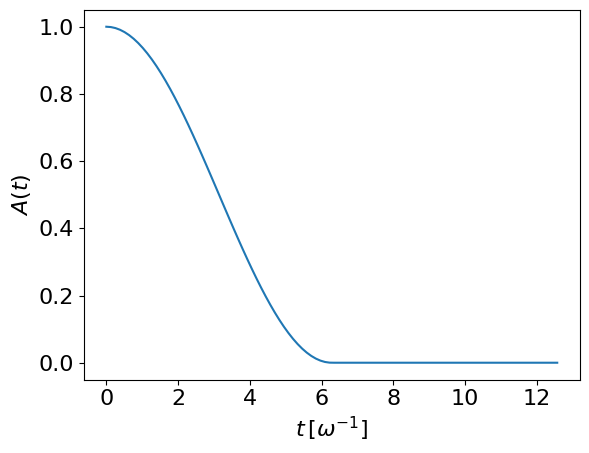

In [77]:
t_tensor = torch.linspace(0, period, 100)
potential_scaling_function = potential_scaling_function(t_tensor, potential_scaling=True)
%matplotlib inline
fig, ax = plt.subplots()

ax.plot(t_tensor, potential_scaling_function, label='Potential scaling')

ax.set_xlabel(r"$t\,[\omega^{-1}]$", fontsize=16)
ax.set_ylabel(r'$A(t)$', fontsize=16)
#ax.legend()

plt.show()
fig.savefig('Potential_scaling.svg', format='svg', bbox_inches='tight')
